# MNIST CNN với PyTorch

Cấu trúc giống notebook NumPy, chỉ khác phần model/training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct, time, os
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 80

DATA_DIR = Path('../data')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)
print('Data dir:', DATA_DIR.resolve())
print('Model dir:', MODEL_DIR.resolve())

Device: cuda
Data dir: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\data
Model dir: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\models


## 1. Load dữ liệu MNIST từ file idx

In [2]:
def load_mnist_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return data

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train_full = load_mnist_images(DATA_DIR / 'train-images.idx3-ubyte')
y_train_full = load_mnist_labels(DATA_DIR / 'train-labels.idx1-ubyte')
X_test = load_mnist_images(DATA_DIR / 't10k-images.idx3-ubyte')
y_test = load_mnist_labels(DATA_DIR / 't10k-labels.idx1-ubyte')
print('Train:', X_train_full.shape, y_train_full.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [3]:
# Split train/val và normalize
N_VAL = 5000
idx = np.random.permutation(len(X_train_full))
X_val = X_train_full[idx[:N_VAL]]; y_val = y_train_full[idx[:N_VAL]]
X_train = X_train_full[idx[N_VAL:]]; y_train = y_train_full[idx[N_VAL:]]

def prep(X):
    return (X.astype(np.float32)/255.0)[:, None, :, :]

X_train = prep(X_train); X_val = prep(X_val); X_test_t = prep(X_test)
print(X_train.shape, X_val.shape, X_test_t.shape)

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val).long())
test_ds  = TensorDataset(torch.from_numpy(X_test_t),torch.from_numpy(y_test).long())

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

(55000, 1, 28, 28) (5000, 1, 28, 28) (10000, 1, 28, 28)


C:\Users\admin\AppData\Local\Temp\ipykernel_32720\2178671175.py:15: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  test_ds  = TensorDataset(torch.from_numpy(X_test_t),torch.from_numpy(y_test).long())


## 2. EDA

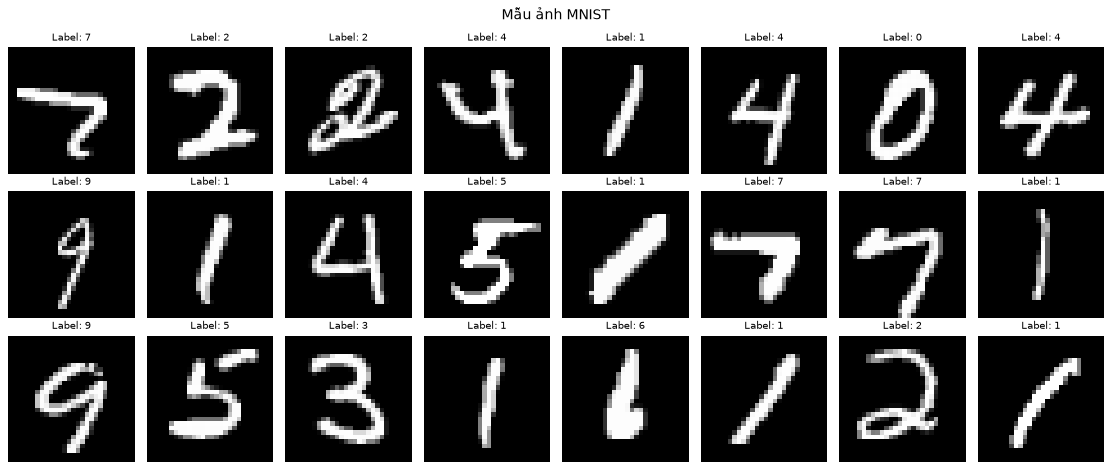

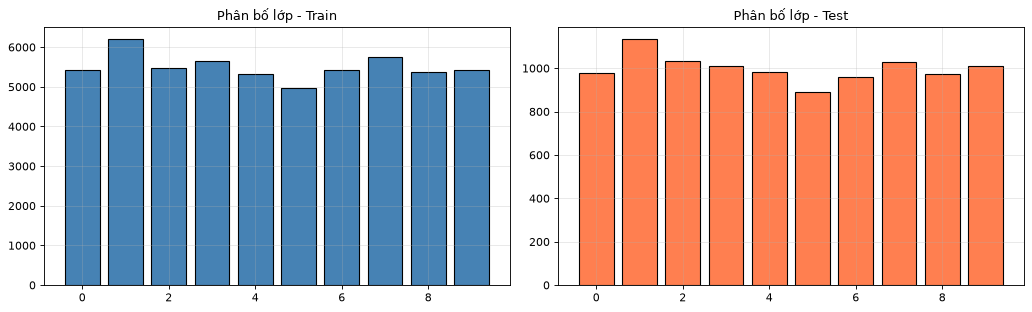

In [4]:
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, 0], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Mẫu ảnh MNIST', fontsize=13)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
u, c = np.unique(y_train, return_counts=True)
axes[0].bar(u, c, color='steelblue', edgecolor='k')
axes[0].set_title('Phân bố lớp - Train'); axes[0].grid(alpha=0.3)
u2, c2 = np.unique(y_test, return_counts=True)
axes[1].bar(u2, c2, color='coral', edgecolor='k')
axes[1].set_title('Phân bố lớp - Test'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Định nghĩa mô hình CNN

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 14x14
        x = self.pool(F.relu(self.conv2(x)))  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN().to(device)
print(model)
print('Params:', sum(p.numel() for p in model.parameters()))

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Params: 206922


## 4. Training

In [6]:
EPOCHS = 5
LR = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def evaluate(loader):
    model.eval()
    loss_sum, correct, n = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss_sum += criterion(out, yb).item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            n += xb.size(0)
    return loss_sum/n, correct/n

history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}
best_acc = 0
best_path = MODEL_DIR / 'mnist_cnn_pytorch.pt'

start = time.time()
for ep in range(EPOCHS):
    model.train()
    loss_sum, correct, n = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    tr_loss = loss_sum/n; tr_acc = correct/n
    val_loss, val_acc = evaluate(val_loader)
    history['loss'].append(tr_loss); history['val_loss'].append(val_loss)
    history['acc'].append(tr_acc);   history['val_acc'].append(val_acc)
    print(f'Epoch {ep+1}/{EPOCHS} - loss {tr_loss:.4f} - acc {tr_acc:.4f} - val_loss {val_loss:.4f} - val_acc {val_acc:.4f}')
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print(f'  -> Saved best model (val_acc={best_acc:.4f})')
print(f'Total time: {time.time()-start:.1f}s')

Epoch 1/5 - loss 0.3919 - acc 0.8803 - val_loss 0.0969 - val_acc 0.9704
  -> Saved best model (val_acc=0.9704)
Epoch 2/5 - loss 0.1017 - acc 0.9689 - val_loss 0.0589 - val_acc 0.9834
  -> Saved best model (val_acc=0.9834)
Epoch 3/5 - loss 0.0711 - acc 0.9783 - val_loss 0.0488 - val_acc 0.9850
  -> Saved best model (val_acc=0.9850)
Epoch 4/5 - loss 0.0552 - acc 0.9832 - val_loss 0.0436 - val_acc 0.9874
  -> Saved best model (val_acc=0.9874)
Epoch 5/5 - loss 0.0462 - acc 0.9852 - val_loss 0.0399 - val_acc 0.9892
  -> Saved best model (val_acc=0.9892)
Total time: 19.8s


## 5. Learning Curves

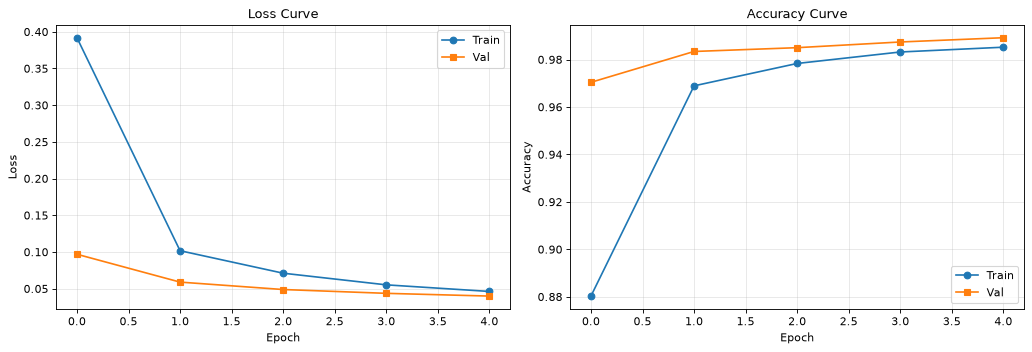

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['loss'], 'o-', label='Train')
axes[0].plot(history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['acc'], 'o-', label='Train')
axes[1].plot(history['val_acc'], 's-', label='Val')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Đánh giá Test set

In [8]:
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()
all_preds = []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(device))
        all_preds.append(out.argmax(1).cpu().numpy())
y_pred = np.concatenate(all_preds)
test_acc = (y_pred == y_test).mean()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9892


## 7. Confusion Matrix

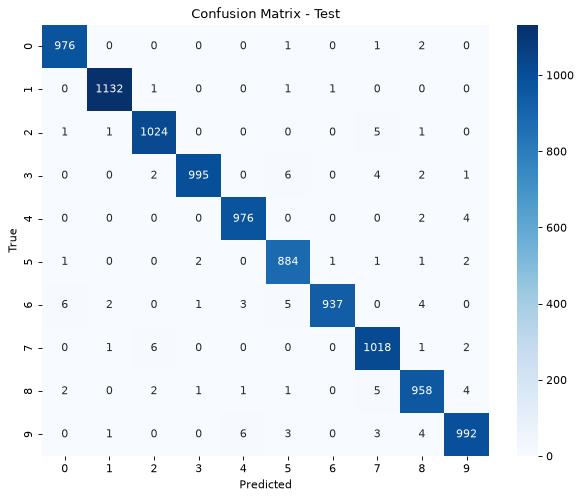

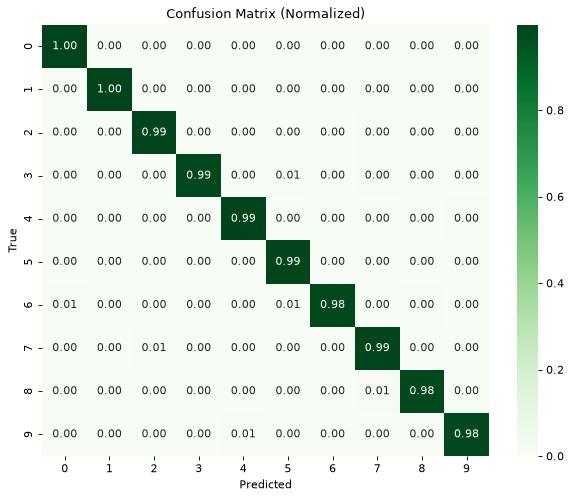

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Test'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

## 8. Classification Report

In [10]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9899    0.9959    0.9929       980
           1     0.9956    0.9974    0.9965      1135
           2     0.9894    0.9922    0.9908      1032
           3     0.9960    0.9851    0.9905      1010
           4     0.9899    0.9939    0.9919       982
           5     0.9811    0.9910    0.9861       892
           6     0.9979    0.9781    0.9879       958
           7     0.9817    0.9903    0.9860      1028
           8     0.9826    0.9836    0.9831       974
           9     0.9871    0.9832    0.9851      1009

    accuracy                         0.9892     10000
   macro avg     0.9891    0.9891    0.9891     10000
weighted avg     0.9892    0.9892    0.9892     10000



## 9. Xem dự đoán sai

Số mẫu sai: 108/10000


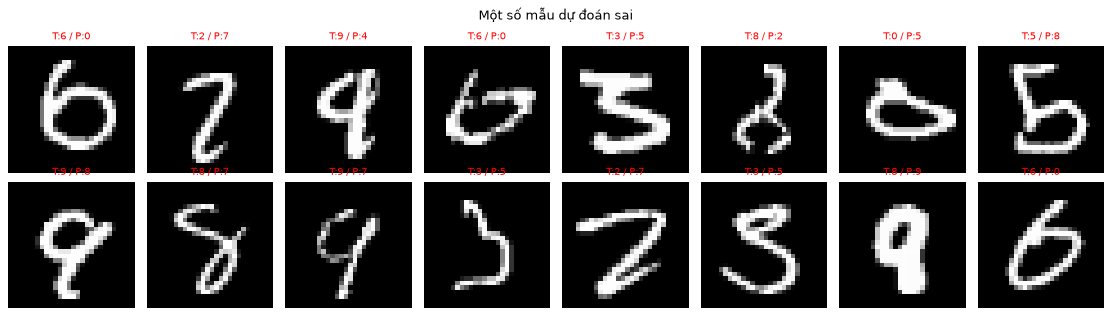

In [11]:
wrong = np.where(y_pred != y_test)[0]
print(f'Số mẫu sai: {len(wrong)}/{len(y_test)}')
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    k = wrong[i]
    ax.imshow(X_test_t[k, 0], cmap='gray')
    ax.set_title(f'T:{y_test[k]} / P:{y_pred[k]}', fontsize=9, color='red')
    ax.axis('off')
plt.suptitle('Một số mẫu dự đoán sai', fontsize=12)
plt.tight_layout(); plt.show()

In [12]:
print('Best model saved at:', best_path.resolve())

Best model saved at: D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 04\mnist\models\mnist_cnn_pytorch.pt
